Below cell is Taken from multimodal.ipynb file

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class CrossAttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout=0.0):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, context, return_attn=False):
        B, T_x, C = x.shape
        q = self.query(x)
        k = self.key(context)
        v = self.value(context)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        wei = F.softmax(wei, dim=-1)
        if return_attn:
            return wei @ v, wei
        out = wei @ v
        return out

class MultiHeadCrossAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout=0.0):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([CrossAttentionHead(n_embd, head_size, dropout) for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, context):
        out = torch.cat([h(x, context) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [6]:
x = torch.randn(2, 10, 64)
context = torch.randn(2, 5, 64)

mha_cross = MultiHeadCrossAttention(n_embd=64, n_head=4)
output = mha_cross(x, context)

print("Query Input Shape:", x.shape)
print("Context Input Shape:", context.shape)
print("Cross-Attention Output Shape:", output.shape)

Query Input Shape: torch.Size([2, 10, 64])
Context Input Shape: torch.Size([2, 5, 64])
Cross-Attention Output Shape: torch.Size([2, 10, 64])


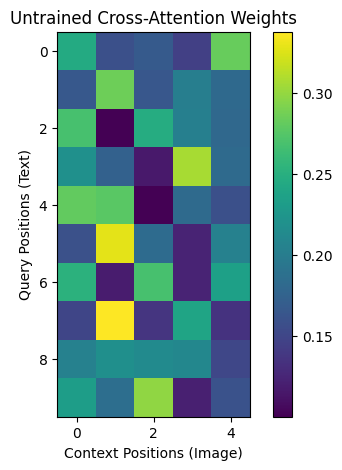

Row sums (Should equal 1.0): [1.         0.99999994 1.         1.         0.99999994 1.0000001
 1.         0.99999994 1.         1.        ]


In [7]:
single_head = mha_cross.heads[0]
_, weights = single_head(x, context, return_attn=True)
attn_matrix = weights[0].detach().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(attn_matrix, cmap='viridis')
plt.xlabel('Context Positions (Image)')
plt.ylabel('Query Positions (Text)')
plt.title('Untrained Cross-Attention Weights')
plt.colorbar()
plt.show()

print("Row sums (Should equal 1.0):", attn_matrix.sum(axis=-1))

In [9]:
with torch.no_grad():
    target_vector = single_head.query(x[0, 5:6])

_, weights_before = single_head(x, context, return_attn=True)
print("Attention from Query 5 to Context 2 before training:", weights_before[0, 5, 2].item())

optimizer = torch.optim.Adam(single_head.parameters(), lr=1e-2)

for step in range(1000):
    optimizer.zero_grad()
    out, weights = single_head(x, context, return_attn=True)
    loss = F.mse_loss(out[0, 5], target_vector.squeeze())
    loss.backward()
    optimizer.step()

_, weights_after = single_head(x, context, return_attn=True)
print("Attention from Query 5 to Context 2 after training:", weights_after[0, 5, 2].item())

Attention from Query 5 to Context 2 before training: 0.28776320815086365
Attention from Query 5 to Context 2 after training: 0.07990991324186325


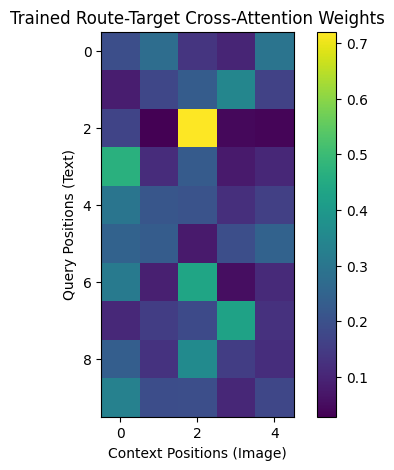

In [10]:
attn_matrix_after = weights_after[0].detach().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(attn_matrix_after, cmap='viridis')
plt.xlabel('Context Positions (Image)')
plt.ylabel('Query Positions (Text)')
plt.title('Trained Route-Target Cross-Attention Weights')
plt.colorbar()
plt.show()